In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df1 = pd.read_csv(r"D:\TS dataset\seasonality.csv")

In [5]:
df1

,Unnamed: 0,date,births
0,1,1/1/2015,8068
1,2,1/2/2015,10850
2,3,1/3/2015,8328
3,4,1/4/2015,7065
4,5,1/5/2015,11892
...,...,...,...
360,361,12/27/2015,7518
361,362,12/28/2015,13100
362,363,12/29/2015,13458
363,364,12/30/2015,13100


In [6]:
df1.columns

Index(['Unnamed: 0', 'date', 'births'], dtype='object')

In [7]:
df1.drop("Unnamed: 0", axis = 1)

,date,births
0,1/1/2015,8068
1,1/2/2015,10850
2,1/3/2015,8328
3,1/4/2015,7065
4,1/5/2015,11892
...,...,...
360,12/27/2015,7518
361,12/28/2015,13100
362,12/29/2015,13458
363,12/30/2015,13100


In [8]:
df1.drop("Unnamed: 0", axis = 1, inplace = True)

In [9]:
df1

,date,births
0,1/1/2015,8068
1,1/2/2015,10850
2,1/3/2015,8328
3,1/4/2015,7065
4,1/5/2015,11892
...,...,...
360,12/27/2015,7518
361,12/28/2015,13100
362,12/29/2015,13458
363,12/30/2015,13100


In [11]:
df1["date"]

0        1/1/2015
1        1/2/2015
2        1/3/2015
3        1/4/2015
4        1/5/2015
          ...    
360    12/27/2015
361    12/28/2015
362    12/29/2015
363    12/30/2015
364    12/31/2015
Name: date, Length: 365, dtype: object

In [12]:
pd.to_datetime(df1["date"])

0     2015-01-01
1     2015-01-02
2     2015-01-03
3     2015-01-04
4     2015-01-05
         ...    
360   2015-12-27
361   2015-12-28
362   2015-12-29
363   2015-12-30
364   2015-12-31
Name: date, Length: 365, dtype: datetime64[ns]

In [13]:
df1["date"] = pd.to_datetime(df1["date"])

In [14]:
df1

,date,births
0,2015-01-01,8068
1,2015-01-02,10850
2,2015-01-03,8328
3,2015-01-04,7065
4,2015-01-05,11892
...,...,...
360,2015-12-27,7518
361,2015-12-28,13100
362,2015-12-29,13458
363,2015-12-30,13100


In [15]:
df1.dtypes

date      datetime64[ns]
births             int64
dtype: object

In [16]:
df1.set_index("date")

,births
date,
2015-01-01,8068
2015-01-02,10850
2015-01-03,8328
2015-01-04,7065
2015-01-05,11892
...,...
2015-12-27,7518
2015-12-28,13100
2015-12-29,13458


In [17]:
df1.set_index("date", inplace = True)

In [18]:
df1

,births
date,
2015-01-01,8068
2015-01-02,10850
2015-01-03,8328
2015-01-04,7065
2015-01-05,11892
...,...
2015-12-27,7518
2015-12-28,13100
2015-12-29,13458


In [19]:
df1["births"]

date
2015-01-01     8068
2015-01-02    10850
2015-01-03     8328
2015-01-04     7065
2015-01-05    11892
              ...  
2015-12-27     7518
2015-12-28    13100
2015-12-29    13458
2015-12-30    13100
2015-12-31    11608
Name: births, Length: 365, dtype: int64

<Axes: xlabel='date'>

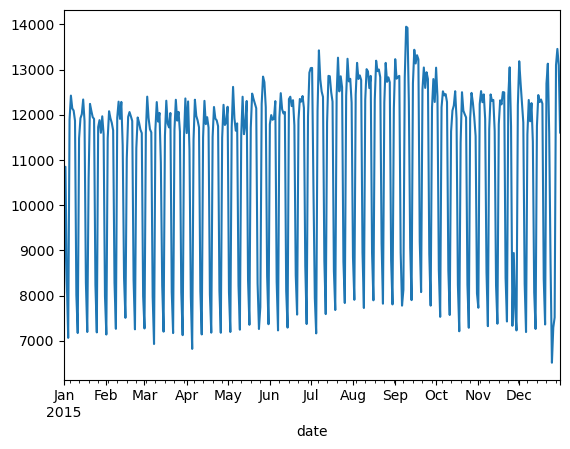

In [20]:
df1["births"].plot()

In [21]:
from statsmodels.tsa.stattools import adfuller

In [22]:
adf1 = adfuller(df1["births"])

In [23]:
adf1

(np.float64(-1.601399361747583),
 np.float64(0.4828904860666182),
 14,
 350,
 {'1%': np.float64(-3.4491725955218655),
  '5%': np.float64(-2.8698334971428574),
  '10%': np.float64(-2.5711883591836733)},
 np.float64(5513.1042619844475))

### Difference 

In [24]:
births = np.diff(df1["births"], n= 20)

In [25]:
births

array([-163724038,  244311719, -257450049,  222146528, -164988462,
         95603782,  -16739749,  -57581720,  109248405, -134338788,
        137805094, -111222201,   34816451,   88512096, -213803808,
        284511473, -280255464,  223069372, -139791797,   36384945,
         84245503, -196740363,  264394882, -271545863,  229130988,
       -149267620,   33672456,  103737984, -219047702,  263504440,
       -226545509,  141322137,  -46920839,  -42111714,  125862180,
       -195559823,  235202695, -240163198,  217610026, -167556161,
         79673920,   42339221, -164762001,  246003057, -271145166,
        252917304, -201994936,  114170472,    6542473, -127878916,
        208597208, -232924319,  211914977, -154258516,   56046943,
         72279211, -185824495,  231648899, -194082901,  101838392,
          7789419, -116685213,  215852001, -287533073,  315039614,
       -303370941,  271225471, -221139491,  135431506,  -11015701,
       -115589850,  193795253, -204740380,  168073860, -107270

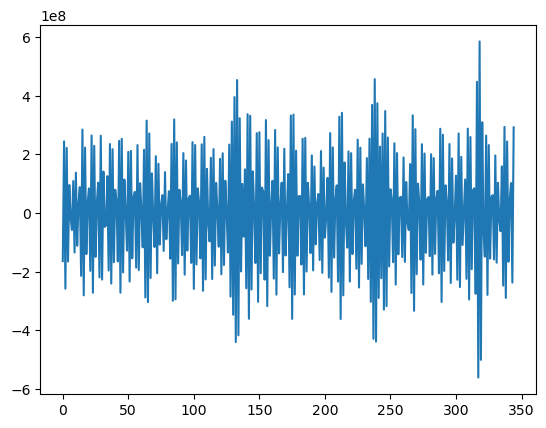

In [26]:
plt.plot(births)

In [27]:
adf2 = adfuller(births)

In [28]:
adf2

(np.float64(-26.502525570683183),
 0.0,
 17,
 327,
 {'1%': np.float64(-3.45050711373316),
  '5%': np.float64(-2.8704195794076743),
  '10%': np.float64(-2.571500856923753)},
 np.float64(8676.122580551975))

In [29]:
df1

,births
date,
2015-01-01,8068
2015-01-02,10850
2015-01-03,8328
2015-01-04,7065
2015-01-05,11892
...,...
2015-12-27,7518
2015-12-28,13100
2015-12-29,13458


In [30]:
np.sort(df1["births"])

array([ 6515,  6821,  6929,  7065,  7125,  7139,  7141,  7164,  7171,
        7172,  7178,  7180,  7186,  7194,  7195,  7195,  7202,  7211,
        7230,  7230,  7246,  7254,  7261,  7262,  7265,  7273,  7288,
        7292,  7294,  7324,  7332,  7354,  7361,  7367,  7371,  7378,
        7427,  7508,  7518,  7530,  7571,  7580,  7591,  7681,  7726,
        7731,  7734,  7746,  7778,  7778,  7805,  7821,  7836,  7896,
        7900,  7907,  7944,  7980,  7981,  7987,  7989,  8014,  8028,
        8049,  8068,  8071,  8073,  8075,  8078,  8080,  8092,  8101,
        8104,  8127,  8216,  8217,  8221,  8233,  8235,  8239,  8262,
        8267,  8280,  8285,  8313,  8328,  8337,  8343,  8368,  8390,
        8392,  8431,  8451,  8517,  8546,  8550,  8579,  8652,  8714,
        8748,  8769,  8772,  8851,  8927,  8938,  8942,  8950,  8956,
        9062,  9153,  9195, 10375, 10602, 10850, 10940, 11038, 11234,
       11260, 11321, 11388, 11406, 11455, 11479, 11480, 11494, 11500,
       11503, 11513,

In [31]:
sort_births = np.diff(np.sort(df1["births"]), n = 20)

In [32]:
sort_births

array([    127428,    -208017,     169161,    -205943,     451087,
          -920544,    1520030,   -2077786,    2404736,   -2386319,
          2054419,   -1569327,    1112411,    -764688,     449620,
            16929,    -775540,    1761818,   -2681574,    3176720,
         -3055395,    2411653,   -1589112,    1039387,   -1092254,
          1689660,   -2325677,    2426063,   -1934217,    1450604,
         -1634318,    2458571,   -3169628,    2994285,   -1789290,
            15462,    1712806,   -2909064,    3207094,   -2388069,
           593078,    1542833,   -3144614,    3655405,   -3221911,
          2515448,   -2149974,    2262965,   -2583978,    2768693,
         -2620636,    2115568,   -1363972,     569601,      59951,
          -427194,     579088,    -635140,     721350,   -1004110,
          1724666,   -3038489,    4704620,   -6012336,    6224121,
         -5212390,    3622794,   -2357840,    1906483,   -2138687,
          2609491,   -2947738,    3003726,   -2787703,    2366

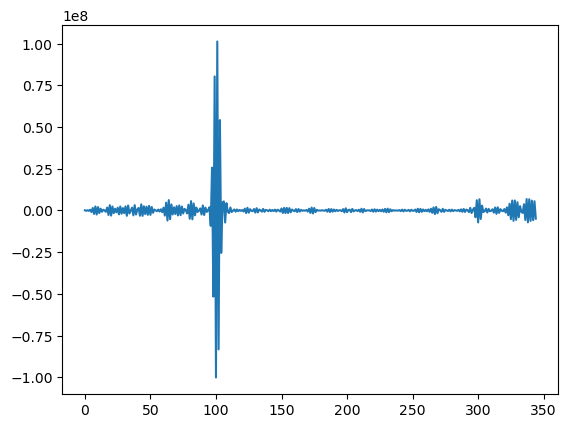

In [33]:
plt.plot(sort_births)

In [34]:
adf3 = adfuller(sort_births)

In [35]:
adf3

(np.float64(-26.143662982899784),
 0.0,
 17,
 327,
 {'1%': np.float64(-3.45050711373316),
  '5%': np.float64(-2.8704195794076743),
  '10%': np.float64(-2.571500856923753)},
 np.float64(6904.141031370849))